# Datos Sociodemográficos y Recursos de Salud en EEUU
**Variable objetivo elegida:** `heart_disease_mortality`
**¿Por qué esta variable?** La mortalidad por enfermedad cardíaca es una de las métricas de salud más directas y completas. Está claramente influenciada por factores sociodemográficos como la pobreza, el acceso a médicos o los hábitos de vida. Es la variable más representativa para este análisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# URL del dataset
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv'

df = pd.read_csv(url)

print(f'El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas')

df.head()

El dataset tiene 3140 filas y 108 columnas


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


#EDA Análisis Exploratorio

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Columns: 108 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), str(2)
memory usage: 2.6 MB


TOT_POP — Población total

Media: 104.000 habitantes por condado
Pero la desviación típica es 333.000 muchísima variabilidad (es muy dispersa)
Mínimo: 88 habitantes y seguramente el máximo será millones

Urban_rural_code:Media de 4.6 significa que la mayoría de condados son semi-rurales o rurales

In [4]:
df.describe()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
count,3140.000000,3.140000e+03,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,3.140000e+03,3140.000000,...,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000,3140.000000
mean,30401.640764,1.041894e+05,1.274030e+04,11.871051,1.336798e+04,12.694609,1.446933e+04,12.283979,1.391649e+04,11.751535,...,5827.242357,13.073503,12.088089,14.053726,9326.577707,3.446242,3.207516,3.710478,2466.234076,4.635350
std,15150.559265,3.335834e+05,4.180730e+04,2.124081,4.228439e+04,1.815044,4.957773e+04,3.126297,4.899095e+04,1.696599,...,15720.551934,2.724351,2.622948,2.824828,29754.601185,0.568059,0.527740,0.613069,7730.422067,1.510447
min,1001.000000,8.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.100000e+01,6.092789,...,7.000000,6.100000,5.500000,6.700000,11.000000,1.800000,1.700000,1.900000,3.000000,1.000000
25%,18180.500000,1.096325e+04,1.280500e+03,10.594639,1.374500e+03,11.674504,1.263750e+03,10.496774,1.232750e+03,10.689322,...,815.000000,11.200000,10.300000,12.100000,1187.750000,3.100000,2.900000,3.300000,314.750000,3.000000
50%,29178.000000,2.580050e+04,3.057000e+03,11.802727,3.274000e+03,12.687422,3.108000e+03,11.772649,3.000500e+03,11.580861,...,1963.500000,12.800000,11.800000,13.800000,2743.000000,3.400000,3.200000,3.700000,718.000000,5.000000
75%,45081.500000,6.791300e+04,8.097000e+03,12.951840,8.822250e+03,13.659282,8.976250e+03,13.182260,8.314250e+03,12.639379,...,4727.000000,14.800000,13.700000,15.900000,6679.250000,3.800000,3.500000,4.100000,1776.250000,6.000000
max,56045.000000,1.010552e+07,1.208253e+06,25.460677,1.239139e+06,23.304372,1.557073e+06,37.570198,1.501844e+06,22.225129,...,434075.000000,25.600000,24.200000,27.000000,952335.000000,6.200000,5.800000,6.600000,237766.000000,6.000000


no hay ninguna columna con valores nulos.

In [7]:
# Contamos cuántos valores nulos hay en cada columna
nulos = df.isnull().sum()
print(nulos[nulos > 0])

Series([], dtype: int64)


#Análisis de la variable Objetivo: heart_disease_mortality-->Heart disease_number 


In [9]:
# Buscamos columnas que contengan la palabra 'heart' o 'disease'
for col in df.columns:
    if 'heart' in col.lower() or 'disease' in col.lower():
        print(col)


Heart disease_prevalence
Heart disease_Lower 95% CI
Heart disease_Upper 95% CI
Heart disease_number


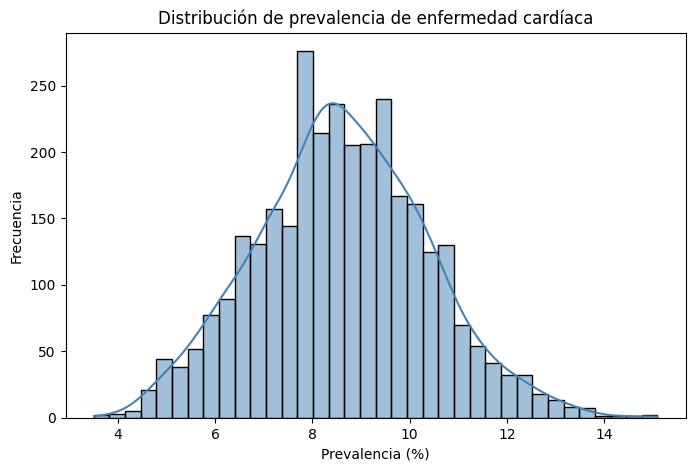

In [14]:
#Gráfico 1: Histograma - cómo se distribuyen los valores
#cogi Heart disease_prevalence porque está  poercentaje la variable objetivo al estar en valores aboluto
# no se veía nada en las gráficas

plt.figure(figsize=(8, 5))
sns.histplot(df["Heart disease_prevalence"], kde=True, color='steelblue')
plt.title('Distribución de prevalencia de enfermedad cardíaca')
plt.xlabel('Prevalencia (%)')
plt.ylabel('Frecuencia')
plt.show()

Los outlier de arriba algunos condados tienen una prevalencia muy alta de enfermedad cardíaca. Son condados con población muy envejecida o con malos recursos sanitarios.

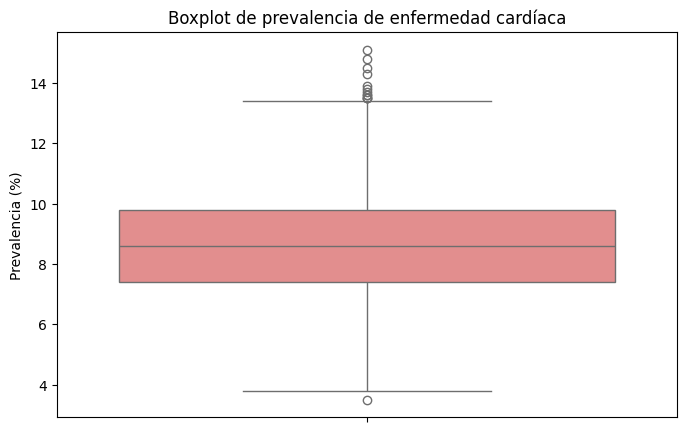

In [15]:
# Gráfico 2: Boxplot - para ver si hay valores atípicos (outliers)
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Heart disease_prevalence'], color='lightcoral')
plt.title('Boxplot de prevalencia de enfermedad cardíaca')
plt.ylabel('Prevalencia (%)')
plt.show()

In [17]:
#MAPA DE CORRELACIÓN CON LA VARIABLE OBJETIVO 

correlaciones = (df.select_dtypes(include='number').corr()['Heart disease_prevalence'] .drop('Heart disease_prevalence')   
                   .abs().sort_values(ascending=False)) 

print('Top 10 variables más correlacionadas con heart_disease_mortality:')
print(correlaciones.head(10))

Top 10 variables más correlacionadas con heart_disease_mortality:
Heart disease_Upper 95% CI    0.997752
Heart disease_Lower 95% CI    0.997441
CKD_Upper 95% CI              0.908082
CKD_prevalence                0.892792
COPD_Upper 95% CI             0.890111
COPD_prevalence               0.886726
COPD_Lower 95% CI             0.877945
CKD_Lower 95% CI              0.874806
diabetes_Upper 95% CI         0.850717
diabetes_prevalence           0.831021
Name: Heart disease_prevalence, dtype: float64


Selección de variables 

In [18]:
#NOS QUEDAMOS SOLO CON COLUMNAS NUMÉRICAS

df_numerico = df.select_dtypes(include='number')

print(f'Columnas numéricas disponibles: {df_numerico.shape[1]}')

Columnas numéricas disponibles: 106


In [26]:
#ELIMINAMOS COLUMNAS QUE CAUSAN DATA LEAKAGE, cuando tenemos columnas muy relacionadas con la variable objeto

df_numerico = df_numerico.drop(['Heart disease_number','Heart disease_Lower 95% CI','Heart disease_Upper 95% CI'], axis=1)

print(f'Columnas eliminadas. Nuevo tamaño: {df_numerico.shape}')

Columnas eliminadas. Nuevo tamaño: (3140, 103)


In [27]:
#SEPARAMOS X  e Y (variable a predecir)

X = df_numerico.drop('Heart disease_prevalence', axis=1)

y = df_numerico['Heart disease_prevalence']

print(f'Forma de X: {X.shape}')
print(f'Forma de y: {y.shape}')

Forma de X: (3140, 102)
Forma de y: (3140,)


In [28]:
#DIVIDIMOS EN TRAIN Y TEST

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Modelo de Regresión Lineal

In [29]:
# Creamos el modelo
modelo_lr = LinearRegression()

In [30]:
#entrenamos el modelo con los datos de entrenamiento
modelo_lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
#predecimos los valores del test
y_pred_lr = modelo_lr.predict(X_test)

Las métricas tienen unos resultados muy buenos aunque como se ha vistoe en describe hay muchas columnas relacionadas
con Heart disease_prevalence, como : Heart disease_number, Heart disease_Lower 95% CI, Heart disease_Upper 95% CI por eso las eliminamos antes. Y se optiene unos resultados excelentes.

In [32]:
#CALCULAMOS LAS MÉTRICAS 
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f'  MAE:  {mae_lr:.2f}')
print(f'  MSE:  {mse_lr:.2f}')
print(f'  RMSE: {rmse_lr:.2f}')
print(f'  R²:   {r2_lr:.4f}')

  MAE:  0.18
  MSE:  0.06
  RMSE: 0.24
  R²:   0.9822


#Modelo Lasso

In [33]:
# Por defecto Lasso usa alpha=1.0
modelo_lasso = Lasso()

In [34]:
#Lo entrenamos
modelo_lasso.fit(X_train, y_train)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.018e+03, tolerance: 7.676e-01
  model = cd_fast.enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [35]:
# Predecimos
y_pred_lasso = modelo_lasso.predict(X_test)

Nos da unas peores métricas que antes pero porque Lasso pone aquellas variables que cosidera inúteles a cero
pero sigue teniendo muy buenas métricas

In [36]:
# Métricas
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso  = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso   = r2_score(y_test, y_pred_lasso)

print(f'  MAE:  {mae_lasso:.2f}')
print(f'  MSE:  {mse_lasso:.2f}')
print(f'  RMSE: {rmse_lasso:.2f}')
print(f'  R²:   {r2_lasso:.4f}')

  MAE:  0.54
  MSE:  0.53
  RMSE: 0.73
  R²:   0.8364


In [37]:
#COMPARACIÓN: REGRESIÓN LINEAL vs LASSO

print(f'  Métrica   Reg. Lineal     Lasso')
print(f'  MAE:      {mae_lr:>10.2f}    {mae_lasso:>10.2f}')
print(f'  RMSE:     {rmse_lr:>10.2f}    {rmse_lasso:>10.2f}')
print(f'  R²:       {r2_lr:>10.4f}    {r2_lasso:>10.4f}')

  Métrica   Reg. Lineal     Lasso
  MAE:            0.18          0.54
  RMSE:           0.24          0.73
  R²:           0.9822        0.8364


In [39]:
# Nota: usamos 0.1 en lugar de 0.0 porque Lasso con alpha=0 da error

valores_alpha = np.arange(0.1, 20, 0.5)
lista_r2 = []

# un bucle que prueba alphas del 0.1 al 20
for alpha in valores_alpha:
    lasso_temp = Lasso(alpha=alpha, max_iter=10000)
    lasso_temp.fit(X_train, y_train)
    y_pred_temp = lasso_temp.predict(X_test)
    r2_temp = r2_score(y_test, y_pred_temp)
    lista_r2.append(r2_temp)

mejor_posicion = np.argmax(lista_r2)
mejor_alpha    = valores_alpha[mejor_posicion]
mejor_r2       = lista_r2[mejor_posicion]

print(f'Mejor alpha encontrado: {mejor_alpha:.1f} con R² = {mejor_r2:.4f}')

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.824e+02, tolerance: 7.676e-01
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.895e+02, tolerance: 7.676e-01
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1

Mejor alpha encontrado: 0.1 con R² = 0.9650


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.403e+02, tolerance: 7.676e-01
  model = cd_fast.enet_coordinate_descent(


Aqui no dice la gráfica que el punto más alto de r2 es 1.0 porque llega a estar por encima de 0.95. Con un alpha de 0.1. Por que aquí tiene poca penalización, y al ver la línea baja nos indica que cuanto más aumenta alpha penaliza 
más. Por lo que nos indica que este dataset todos sus variables son útiles y con poca penalización funciona mejor.

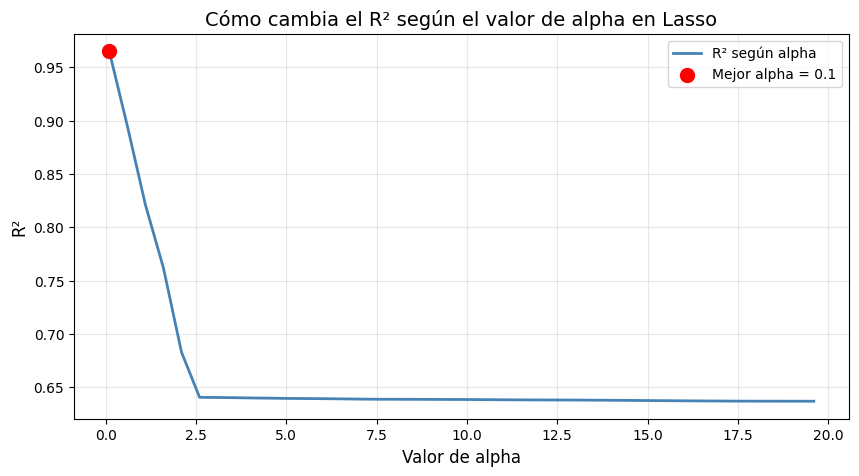

In [40]:
#GRÁFICO DE LÍNEAS: R² según alpha

plt.figure(figsize=(10, 5))
plt.plot(valores_alpha, lista_r2, color='steelblue', linewidth=2, label='R² según alpha')
plt.scatter(mejor_alpha, mejor_r2, color='red', s=100, zorder=5, label=f'Mejor alpha = {mejor_alpha:.1f}')
plt.xlabel('Valor de alpha', fontsize=12)
plt.ylabel('R²', fontsize=12)
plt.title('Cómo cambia el R² según el valor de alpha en Lasso', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)  
plt.show()

#Optimización con Grid Search

In [41]:
# Buscamos valores más precisos alrededor del mejor alpha (0.1) de lo que vimos en la gráfica
valores_a_probar = {'alpha': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]}

In [42]:
grid_search = GridSearchCV(estimator=Lasso(), param_grid=valores_a_probar, cv=5, scoring='r2')

In [43]:
# Entrenamos el Grid Search
grid_search.fit(X_train, y_train)

print(f'Mejor alpha: {grid_search.best_params_}')
print(f'R2 en validación: {grid_search.best_score_:.4f}')

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.228e+01, tolerance: 6.154e-01
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.049e+01, tolerance: 6.194e-01
  model = cd_fast.enet_coordinate_descent(
/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9

Mejor alpha: {'alpha': 0.01}
R2 en validación: 0.9773


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.149e+02, tolerance: 7.676e-01
  model = cd_fast.enet_coordinate_descent(
